In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import seaborn as sns
import os

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
print(os.listdir())

['.config', 'trum_tweet_sentiment_analysis (1).csv', 'sample_data']


In [6]:
df = pd.read_csv('trum_tweet_sentiment_analysis (1).csv', on_bad_lines='skip', engine='python')
print(df.shape)
print(df.head())
print(df['Sentiment'].value_counts())

(1850123, 2)
                                                text  Sentiment
0  RT @JohnLeguizamo: #trump not draining swamp b...          0
1  ICYMI: Hackers Rig FM Radio Stations To Play A...          0
2  Trump protests: LGBTQ rally in New York https:...          1
3  "Hi I'm Piers Morgan. David Beckham is awful b...          0
4  RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...          0
Sentiment
0    1244211
1     605912
Name: count, dtype: int64


In [7]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r"don't", 'do not', text)
    text = re.sub(r"can't", 'cannot', text)
    text = re.sub(r"won't", 'will not', text)
    text = re.sub(r"n't", ' not', text)
    text = re.sub(r"'re", ' are', text)
    text = re.sub(r"'s", ' is', text)
    text = re.sub(r"'d", ' would', text)
    text = re.sub(r"'ll", ' will', text)
    text = re.sub(r"'ve", ' have', text)
    text = re.sub(r"'m", ' am', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(preprocess_text)
print(df[['text', 'Sentiment', 'cleaned_text']].head())

                                                text  Sentiment  \
0  RT @JohnLeguizamo: #trump not draining swamp b...          0   
1  ICYMI: Hackers Rig FM Radio Stations To Play A...          0   
2  Trump protests: LGBTQ rally in New York https:...          1   
3  "Hi I'm Piers Morgan. David Beckham is awful b...          0   
4  RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...          0   

                                        cleaned_text  
0  rt trump draining swamp taxpayer dollar trip a...  
1  icymi hacker rig fm radio station play antitru...  
2    trump protest lgbtq rally new york bbcworld via  
3  hi pier morgan david beckham awful donald trum...  
4  rt tech firm suing buzzfeed publishing unverif...  


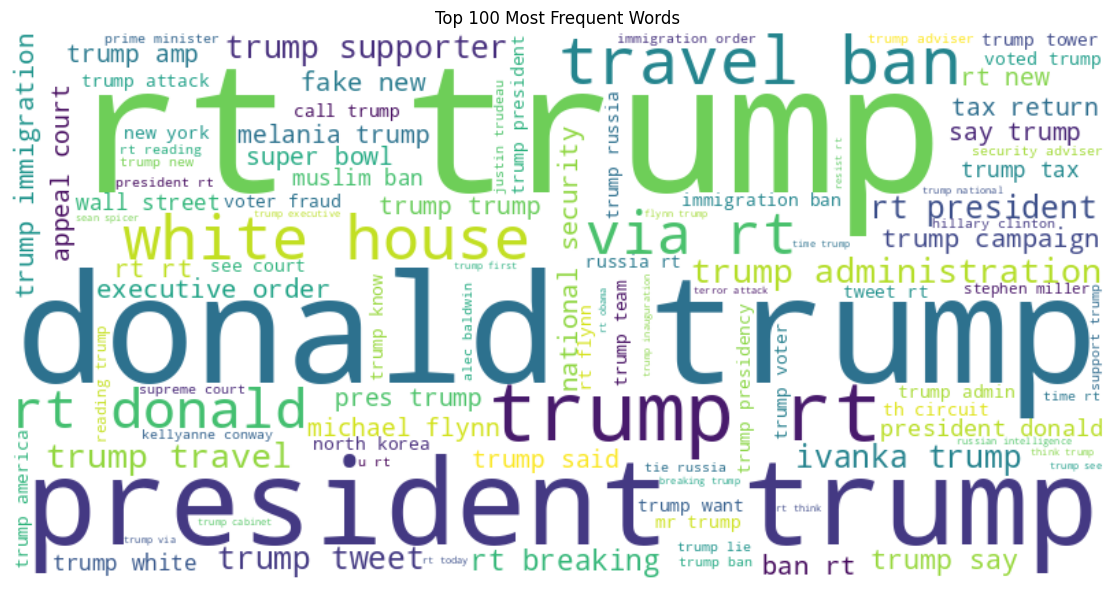

In [8]:
all_words = ' '.join(df['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words')
plt.tight_layout()
plt.show()

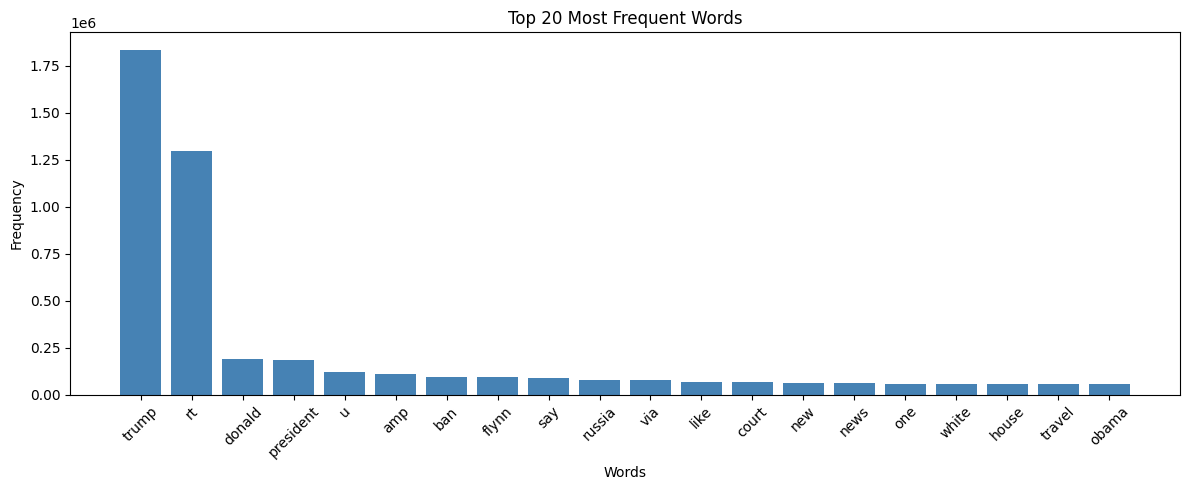

In [9]:
from collections import Counter

word_freq = Counter(' '.join(df['cleaned_text']).split())
common_words = word_freq.most_common(20)
words, counts = zip(*common_words)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['Sentiment'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'],
    df['sentiment_encoded'],
    test_size=0.2,
    random_state=42
)

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')

{np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
Train size: 1480098, Test size: 370025


In [11]:
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

seq_lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(seq_lengths, 95))
print(f'95th percentile sequence length (max_len): {max_len}')

95th percentile sequence length (max_len): 16


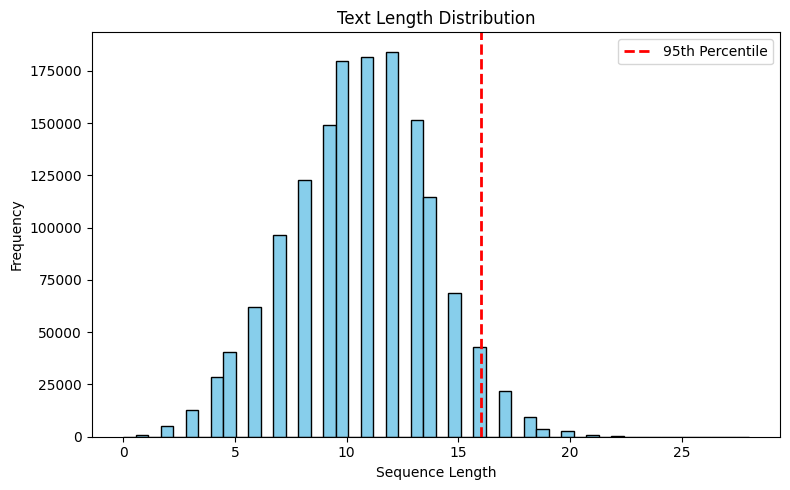

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(seq_lengths, bins=50, color='skyblue', edgecolor='black')
plt.axvline(np.percentile(seq_lengths, 95), color='red', linestyle='dashed', linewidth=2, label='95th Percentile')
plt.title('Text Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad shape: {X_test_pad.shape}')

X_train_pad shape: (1480098, 16)
X_test_pad shape: (370025, 16)


In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

# Example parameters
vocab_size = 10000
embedding_dim = 128
max_length = 100
rnn_units = 64

# Build the model
rnn_model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(rnn_units),
    Dense(1, activation='sigmoid')
])
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
rnn_model.summary()


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)        │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_17 (SimpleRNN)       │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
lstm_model = Sequential([
    Input(shape=(max_len,)),                          # ← same here
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(rnn_units),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ (None, 16, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
rnn_checkpoint = ModelCheckpoint('best_rnn_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test),
    callbacks=[rnn_checkpoint, early_stop]
)

Epoch 1/10
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9209 - loss: 0.2006
Epoch 1: val_accuracy improved from None to 0.95968, saving model to best_rnn_model.h5



Epoch 1: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 117s 5ms/step - accuracy: 0.9434 - loss: 0.1530 - val_accuracy: 0.9597 - val_loss: 0.1175
Epoch 2/10
23119/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9649 - loss: 0.1019
Epoch 2: val_accuracy improved from 0.95968 to 0.96320, saving model to best_rnn_model.h5



Epoch 2: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 108s 5ms/step - accuracy: 0.9649 - loss: 0.1021 - val_accuracy: 0.9632 - val_loss: 0.1084
Epoch 3/10
23117/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9706 - loss: 0.0866
Epoch 3: val_accuracy improved from 0.96320 to 0.96381, saving model to best_rnn_model.h5



Epoch 3: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 107s 5ms/step - accuracy: 0.9697 - loss: 0.0891 - val_accuracy: 0.9638 - val_loss: 0.1047
Epoch 4/10
23117/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9738 - loss: 0.0776
Epoch 4: val_accuracy did not improve from 0.96381
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 108s 5ms/step - accuracy: 0.9726 - loss: 0.0812 - val_accuracy: 0.9632 - val_loss: 0.1060
Epoch 5/10
23121/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9755 - loss: 0.0735
Epoch 5: val_accuracy improved from 0.96381 to 0.96448, saving model to best_rnn_model.h5



Epoch 5: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 107s 5ms/step - accuracy: 0.9741 - loss: 0.0772 - val_accuracy: 0.9645 - val_loss: 0.1066
Epoch 6/10
23123/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9762 - loss: 0.0712
Epoch 6: val_accuracy improved from 0.96448 to 0.96571, saving model to best_rnn_model.h5



Epoch 6: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 108s 5ms/step - accuracy: 0.9751 - loss: 0.0745 - val_accuracy: 0.9657 - val_loss: 0.1085
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


In [40]:
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
lstm_checkpoint = ModelCheckpoint('best_lstm_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test),
    callbacks=[lstm_checkpoint, early_stop_lstm]
)

Epoch 1/10
23119/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9240 - loss: 0.1919
Epoch 1: val_accuracy improved from None to 0.96388, saving model to best_lstm_model.h5



Epoch 1: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 183s 7ms/step - accuracy: 0.9474 - loss: 0.1419 - val_accuracy: 0.9639 - val_loss: 0.1037
Epoch 2/10
23126/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9682 - loss: 0.0921
Epoch 2: val_accuracy improved from 0.96388 to 0.96962, saving model to best_lstm_model.h5



Epoch 2: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 191s 7ms/step - accuracy: 0.9691 - loss: 0.0901 - val_accuracy: 0.9696 - val_loss: 0.0912
Epoch 3/10
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9760 - loss: 0.0712
Epoch 3: val_accuracy improved from 0.96962 to 0.97159, saving model to best_lstm_model.h5



Epoch 3: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 167s 7ms/step - accuracy: 0.9757 - loss: 0.0720 - val_accuracy: 0.9716 - val_loss: 0.0881
Epoch 4/10
23122/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9799 - loss: 0.0591
Epoch 4: val_accuracy improved from 0.97159 to 0.97246, saving model to best_lstm_model.h5



Epoch 4: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 202s 7ms/step - accuracy: 0.9794 - loss: 0.0605 - val_accuracy: 0.9725 - val_loss: 0.0847
Epoch 5/10
23124/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9833 - loss: 0.0490
Epoch 5: val_accuracy improved from 0.97246 to 0.97252, saving model to best_lstm_model.h5



Epoch 5: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 171s 7ms/step - accuracy: 0.9825 - loss: 0.0513 - val_accuracy: 0.9725 - val_loss: 0.0868
Epoch 6/10
23119/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9860 - loss: 0.0415
Epoch 6: val_accuracy improved from 0.97252 to 0.97282, saving model to best_lstm_model.h5



Epoch 6: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 168s 7ms/step - accuracy: 0.9851 - loss: 0.0441 - val_accuracy: 0.9728 - val_loss: 0.0872
Epoch 7/10
23126/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9880 - loss: 0.0357
Epoch 7: val_accuracy improved from 0.97282 to 0.97293, saving model to best_lstm_model.h5



Epoch 7: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 204s 7ms/step - accuracy: 0.9870 - loss: 0.0383 - val_accuracy: 0.9729 - val_loss: 0.0892
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


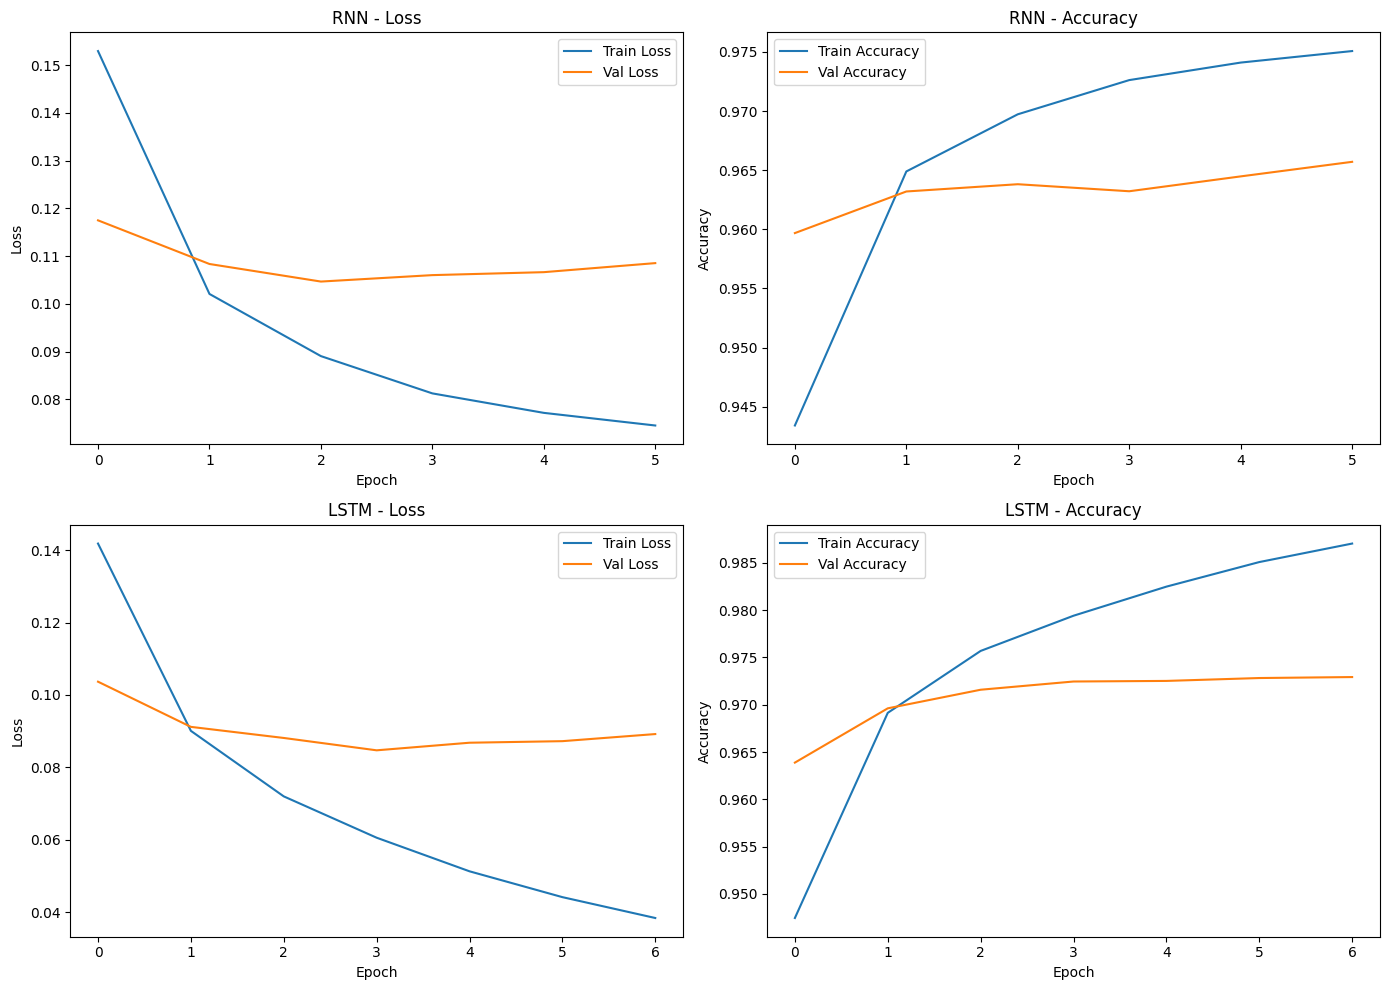

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(rnn_history.history['loss'], label='Train Loss')
axes[0, 0].plot(rnn_history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('RNN - Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

axes[0, 1].plot(rnn_history.history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(rnn_history.history['val_accuracy'], label='Val Accuracy')
axes[0, 1].set_title('RNN - Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

axes[1, 0].plot(lstm_history.history['loss'], label='Train Loss')
axes[1, 0].plot(lstm_history.history['val_loss'], label='Val Loss')
axes[1, 0].set_title('LSTM - Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()

axes[1, 1].plot(lstm_history.history['accuracy'], label='Train Accuracy')
axes[1, 1].plot(lstm_history.history['val_accuracy'], label='Val Accuracy')
axes[1, 1].set_title('LSTM - Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [48]:
rnn_pred_probs = rnn_model.predict(X_test_pad)
rnn_pred = (rnn_pred_probs > 0.5).astype(int).flatten()

lstm_pred_probs = lstm_model.predict(X_test_pad)
lstm_pred = (lstm_pred_probs > 0.5).astype(int).flatten()

print('=== RNN Results ===')
print(f'Accuracy: {accuracy_score(y_test, rnn_pred):.4f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test, rnn_pred))
print('Classification Report:')
print(classification_report(y_test, rnn_pred, target_names=le.classes_.astype(str)))
print('\n=== LSTM Results ===')
print(f'Accuracy: {accuracy_score(y_test, lstm_pred):.4f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test, lstm_pred))
print('Classification Report:')
print(classification_report(y_test, lstm_pred, target_names=le.classes_.astype(str)))

11564/11564 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step
11564/11564 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step
=== RNN Results ===
Accuracy: 0.9638
Confusion Matrix:
[[242938   5625]
 [  7765 113697]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97    248563
           1       0.95      0.94      0.94    121462

    accuracy                           0.96    370025
   macro avg       0.96      0.96      0.96    370025
weighted avg       0.96      0.96      0.96    370025


=== LSTM Results ===
Accuracy: 0.9725
Confusion Matrix:
[[244043   4520]
 [  5672 115790]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    248563
           1       0.96      0.95      0.96    121462

    accuracy                           0.97    370025
   macro avg       0.97      0.97      0.97    370025
weighted avg       0.97      0.97      0.97    370025



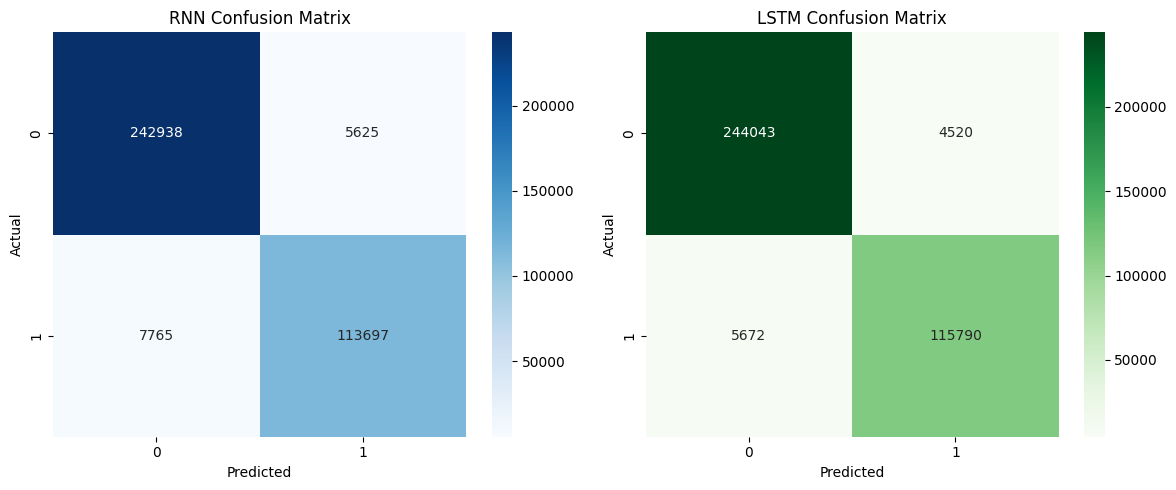

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, rnn_pred), annot=True, fmt='d', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
axes[0].set_title('RNN Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, lstm_pred), annot=True, fmt='d', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Greens')
axes[1].set_title('LSTM Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

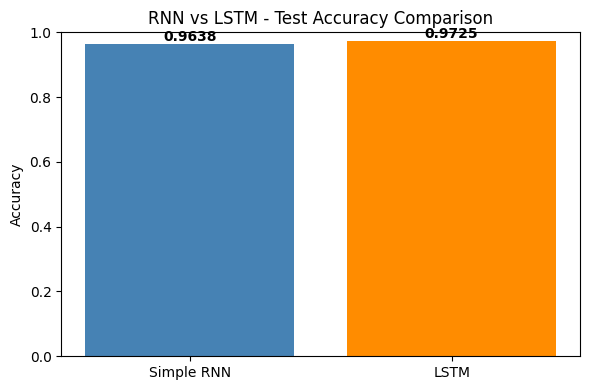

In [46]:
rnn_acc = accuracy_score(y_test, rnn_pred)
lstm_acc = accuracy_score(y_test, lstm_pred)

plt.figure(figsize=(6, 4))
plt.bar(['Simple RNN', 'LSTM'], [rnn_acc, lstm_acc], color=['steelblue', 'darkorange'])
plt.title('RNN vs LSTM - Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate([rnn_acc, lstm_acc]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
def predict_sentiment(text, model, tokenizer, max_len, le):
    cleaned = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prob = model.predict(padded, verbose=0)[0][0]
    label = le.classes_[int(prob > 0.5)]
    return label, prob

test_tweets = [
    "I absolutely love this product, it's amazing!",
    "This is the worst experience I've ever had.",
    "It was okay, nothing special."
]

print('LSTM Predictions:')
for tweet in test_tweets:
    label, prob = predict_sentiment(tweet, lstm_model, tokenizer, max_len, le)
    print(f'  Tweet: "{tweet}"')
    print(f'  Sentiment: {label} (confidence: {prob:.4f})\n')

LSTM Predictions:
  Tweet: "I absolutely love this product, it's amazing!"
  Sentiment: 1 (confidence: 0.9943)

  Tweet: "This is the worst experience I've ever had."
  Sentiment: 0 (confidence: 0.0001)

  Tweet: "It was okay, nothing special."
  Sentiment: 1 (confidence: 0.9794)

